# Pipeline de entrenamiento para Chákṣu

Este notebook construye el pipeline común de entrada que será utilizado para
los experimentos con ResNet50V2 y EfficientNetV2-M.

Objetivos:

1. Cargar las particiones experimentales previamente congeladas.
2. Reutilizar el preprocesamiento geométrico validado.
3. Construir datasets reproducibles con TensorFlow.
4. Aplicar Data Augmentation exclusivamente al subconjunto Train.
5. Definir una estrategia para el desbalance de clases utilizando únicamente Train.
6. Mantener Validation y Test sin augmentation.
7. Verificar dimensiones, etiquetas y distribución antes del entrenamiento.

Este notebook no entrena todavía ninguna arquitectura CNN.

## 1. Importaciones

Importación de librerías para manejo de rutas, visión por computadora con OpenCV, manipulación numérica, análisis tabular, visualización gráfica, construcción de pipelines de datos con TensorFlow y cálculo de ponderaciones de clase con Scikit-learn.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
print("GPU disponibles:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU disponibles: []


## 2. Configuración general

Definición de las rutas del proyecto, fijación de una semilla pseudoaleatoria común (`RANDOM_STATE = 42`) en TensorFlow y NumPy para favorecer la reproducibilidad de los experimentos, y establecimiento de la resolución espacial estándar de 384 × 384 píxeles.

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\SeuNg720\Documents\TP1-RetiScan"
)
CHAKSU_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "glaucoma"
    / "chaksu"
)
METADATA_DIR = CHAKSU_ROOT / "metadata"
SPLITS_PATH = (
    METADATA_DIR
    / "chaksu_splits.csv"
)
IMAGE_SIZE = 384
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## 3. Cargar los splits congelados

Carga del archivo de particiones `chaksu_splits.csv`, confirmando los tamaños (Train: 807, Validation: 202, Test: 336) y la distribución estratificada de clases en cada subconjunto.

In [3]:
df = pd.read_csv(
    SPLITS_PATH
)
train_df = df[
    df["experimental_split"] == "train"
].copy()
val_df = df[
    df["experimental_split"] == "validation"
].copy()
test_df = df[
    df["experimental_split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain:")
print(train_df["label"].value_counts().sort_index())
print("\nValidation:")
print(val_df["label"].value_counts().sort_index())
print("\nTest:")
print(test_df["label"].value_counts().sort_index())


Train: 807
Validation: 202
Test: 336

Train:
label
0    697
1    110
Name: count, dtype: int64

Validation:
label
0    175
1     27
Name: count, dtype: int64

Test:
label
0    285
1     51
Name: count, dtype: int64


## 4. Reutilizar exactamente el preprocessing geométrico

Se reutilizan sin alteraciones las funciones geométricas validadas en el notebook 04: resolución de rutas, detección de FOV con *convex hull*, ampliación de cuadro delimitador, recorte enmascarado con `cv2.bitwise_and`, padding cuadrado simétrico, redimensionamiento con interpolación `INTER_AREA` y la función unificadora `preprocesar_geometria` con control estricto de excepciones `ValueError`.

In [4]:
def resolver_ruta(ruta_relativa):
    return PROJECT_ROOT / Path(ruta_relativa)

def detectar_fov(imagen_rgb, umbral=10):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )
    _, mascara_inicial = cv2.threshold(
        gris,
        umbral,
        255,
        cv2.THRESH_BINARY
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )
    mascara_limpia = cv2.morphologyEx(
        mascara_inicial,
        cv2.MORPH_CLOSE,
        kernel
    )
    # Buscar componentes conexas
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mascara_limpia,
            connectivity=8
        )
    )
    if num_labels <= 1:
        return None, None
    # Ignorar el fondo (label 0)
    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]
    mayor_componente = (
        1 + np.argmax(areas)
    )
    # Máscara de la componente retinal principal
    mascara_componente = (
        labels == mayor_componente
    ).astype(np.uint8) * 255
    # Buscar el contorno de esa componente
    contornos, _ = cv2.findContours(
        mascara_componente,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contornos) == 0:
        return None, None
    # Seleccionar el contorno más grande
    contorno_principal = max(
        contornos,
        key=cv2.contourArea
    )
    # Crear convex hull para suavizar y completar
    # la periferia del campo retinal
    hull = cv2.convexHull(
        contorno_principal
    )
    # Crear nueva máscara vacía
    mascara_fov = np.zeros_like(
        mascara_componente
    )
    # Rellenar el convex hull
    cv2.fillConvexPoly(
        mascara_fov,
        hull,
        255
    )
    # Bounding box calculado sobre el FOV continuo
    x, y, w, h = cv2.boundingRect(
        hull
    )
    return mascara_fov, (x, y, w, h)

def ampliar_bbox(
    bbox,
    image_width,
    image_height,
    margen=0.02
):
    x, y, w, h = bbox
    margen_x = int(w * margen)
    margen_y = int(h * margen)
    x1 = max(
        0,
        x - margen_x
    )
    y1 = max(
        0,
        y - margen_y
    )
    x2 = min(
        image_width,
        x + w + margen_x
    )
    y2 = min(
        image_height,
        y + h + margen_y
    )
    return x1, y1, x2, y2

def recortar_fov(imagen_rgb):
    mascara, bbox = detectar_fov(
        imagen_rgb
    )
    if bbox is None:
        return imagen_rgb, None
    # Conservar únicamente el campo retinal
    imagen_enmascarada = cv2.bitwise_and(
        imagen_rgb,
        imagen_rgb,
        mask=mascara
    )
    alto, ancho = imagen_rgb.shape[:2]
    x1, y1, x2, y2 = ampliar_bbox(
        bbox,
        image_width=ancho,
        image_height=alto,
        margen=0.02
    )
    recorte = imagen_enmascarada[
        y1:y2,
        x1:x2
    ]
    return recorte, (
        x1,
        y1,
        x2,
        y2
    )

def padding_cuadrado(imagen_rgb):
    alto, ancho = imagen_rgb.shape[:2]
    lado = max(alto, ancho)
    imagen_cuadrada = np.zeros(
        (lado, lado, 3),
        dtype=imagen_rgb.dtype
    )
    y_offset = (lado - alto) // 2
    x_offset = (lado - ancho) // 2
    imagen_cuadrada[
        y_offset:y_offset + alto,
        x_offset:x_offset + ancho
    ] = imagen_rgb
    return imagen_cuadrada

def redimensionar_imagen(
    imagen_rgb,
    size=IMAGE_SIZE
):
    return cv2.resize(
        imagen_rgb,
        (size, size),
        interpolation=cv2.INTER_AREA
    )

def preprocesar_geometria(
    imagen_rgb,
    size=IMAGE_SIZE
):
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    if bbox is None:
        raise ValueError(
            "No se pudo detectar el campo de visión retinal."
        )
    imagen_cuadrada = padding_cuadrado(
        recorte
    )
    imagen_resize = redimensionar_imagen(
        imagen_cuadrada,
        size=size
    )
    return imagen_resize, bbox


## 5. Función de carga y preprocesamiento en Python

Se encapsula la lectura de la imagen desde disco, la decodificación RGB y la ejecución del pipeline geométrico OpenCV/NumPy. Se retorna la imagen en formato `np.float32` conservando el rango [0, 255] sin normalizar prematuramente.

In [5]:
def cargar_y_preprocesar_python(
    image_path,
    label
):
    ruta = resolver_ruta(
        image_path.decode("utf-8")
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    procesada, _ = preprocesar_geometria(
        imagen_rgb,
        size=IMAGE_SIZE
    )
    procesada = procesada.astype(
        np.float32
    )
    return procesada, np.float32(label)


## 6. Wrapper para TensorFlow

Se implementa `cargar_y_preprocesar_tf` utilizando `tf.numpy_function` para integrar el pipeline de OpenCV/Pillow dentro del grafo de TensorFlow, estableciendo estáticamente la forma de los tensores generados: `[384, 384, 3]` para la imagen y `[]` para la etiqueta escalar.

In [6]:
def cargar_y_preprocesar_tf(
    image_path,
    label
):
    imagen, etiqueta = tf.numpy_function(
        func=cargar_y_preprocesar_python,
        inp=[
            image_path,
            label
        ],
        Tout=[
            tf.float32,
            tf.float32
        ]
    )
    imagen.set_shape(
        [IMAGE_SIZE, IMAGE_SIZE, 3]
    )
    etiqueta.set_shape([])
    return imagen, etiqueta


## 7. Construir un dataset base

Definición de `crear_dataset_base` para instanciar pipelines de datos mediante `tf.data.Dataset.from_tensor_slices`, permitiendo mezclado (*shuffle*) determinista y procesamiento concurrente optimizado con `tf.data.AUTOTUNE`.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def crear_dataset_base(
    dataframe,
    shuffle=False
):
    rutas = dataframe[
        "image_path"
    ].astype(str).values
    etiquetas = dataframe[
        "label"
    ].astype(np.float32).values
    ds = tf.data.Dataset.from_tensor_slices(
        (
            rutas,
            etiquetas
        )
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )
    ds = ds.map(
        cargar_y_preprocesar_tf,
        num_parallel_calls=AUTOTUNE
    )
    return ds


## 8. Data Augmentation

Definición de la política común y conservadora de aumentación de datos para retinografías:
- `RandomFlip('horizontal')`: Permite simular lateralidad contralateral; se descarta la inversión vertical para respetar la anatomía polar superior/inferior del disco y arcadas.
- `RandomRotation(factor=0.03)`: Rotaciones sutiles de ~±11° con relleno constante negro.
- `RandomZoom(height_factor=(-0.10, 0.10), fill_mode='constant', fill_value=0.0)`: Zoom isotrópico leve de ±10 %, preservando la relación de aspecto (al omitir o fijar `width_factor=None`) para evitar deformaciones geométricas.
- `RandomContrast(factor=0.10)`: Variaciones moderadas de contraste de ±10 %.

In [8]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),
        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            fill_mode="constant",
            fill_value=0.0
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10
        )
    ],
    name="data_augmentation"
)


## 9. Augmentation solamente para Train

Función para aplicar la capa secuencial de aumentación exclusivamente durante el entrenamiento (`training=True`) y definición del tamaño de lote común `BATCH_SIZE = 8`.

In [9]:
def aplicar_augmentation(
    imagen,
    etiqueta
):
    imagen = data_augmentation(
        imagen,
        training=True
    )
    return imagen, etiqueta

BATCH_SIZE = 8


## 10. Crear los tres pipelines

Instanciación de los pipelines de Train, Validation y Test. Se aplica Data Augmentation única y exclusivamente a `train_ds`, mientras que `val_ds` y `test_ds` permanecen sin aumentación. Todos se configuran con `batch(BATCH_SIZE)` y `prefetch(AUTOTUNE)`.

In [10]:
train_ds = crear_dataset_base(
    train_df,
    shuffle=True
)
val_ds = crear_dataset_base(
    val_df,
    shuffle=False
)
test_ds = crear_dataset_base(
    test_df,
    shuffle=False
)

train_ds = train_ds.map(
    aplicar_augmentation,
    num_parallel_calls=AUTOTUNE
)

train_ds = (
    train_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


## 11. Verificar un batch

Extracción del primer lote de `train_ds` para verificar las dimensiones, el tipo de datos y el formato de las etiquetas generadas por el pipeline.

In [11]:
for imagenes, etiquetas in train_ds.take(1):
    print(
        "Shape imágenes:",
        imagenes.shape
    )
    print(
        "Shape etiquetas:",
        etiquetas.shape
    )
    print(
        "Tipo imágenes:",
        imagenes.dtype
    )
    print(
        "Etiquetas:",
        etiquetas.numpy()
    )


Shape imágenes: (8, 384, 384, 3)
Shape etiquetas: (8,)
Tipo imágenes: <dtype: 'float32'>
Etiquetas: [0. 0. 0. 0. 0. 0. 0. 0.]


## 12. Visualizar el Data Augmentation

Inspección visual de una imagen base de Train procesada a 384 × 384 y generación de 6 variantes aumentadas para comprobar que las transformaciones sean visualmente plausibles y no eliminen información relevante para la clasificación de riesgo.

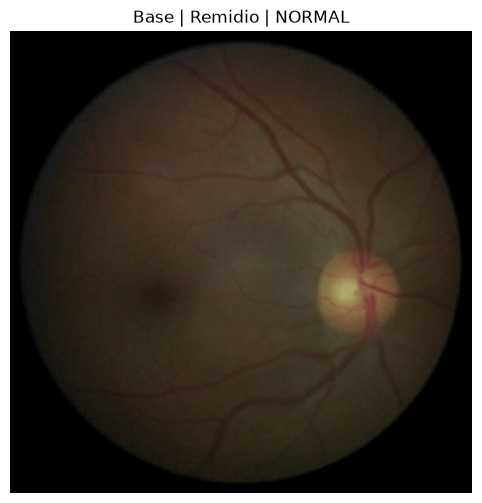

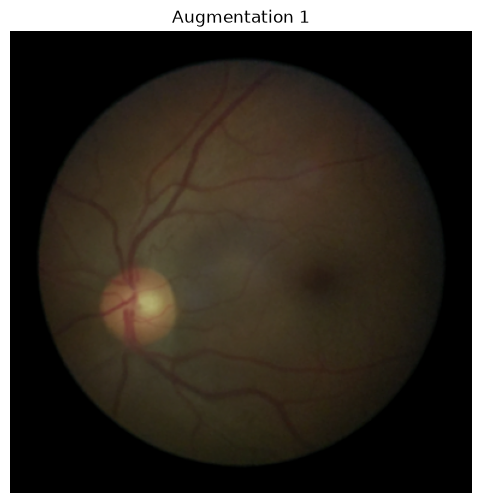

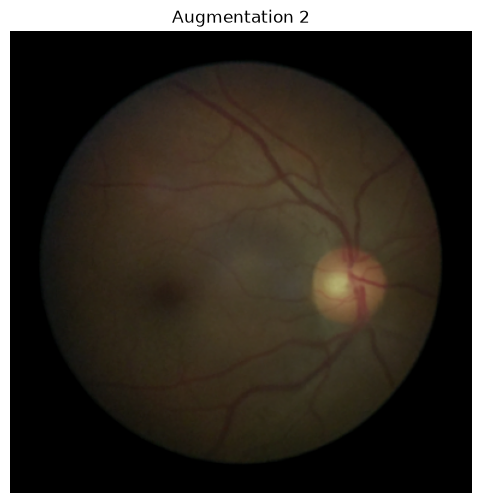

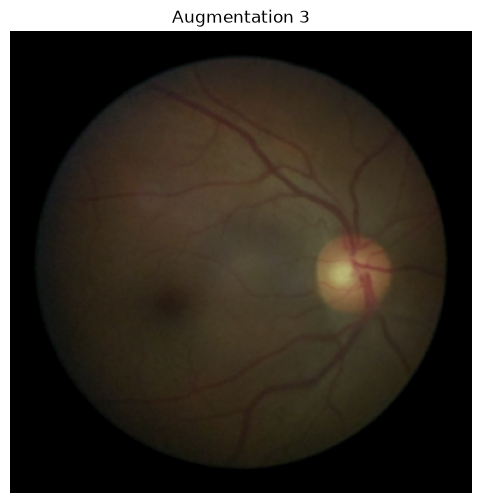

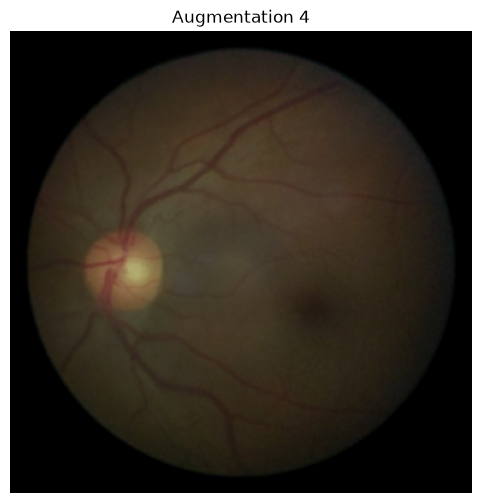

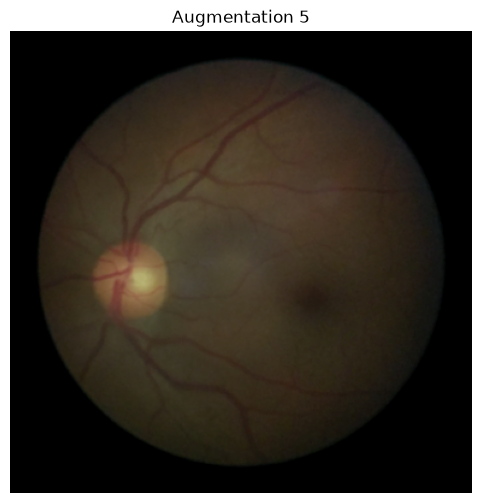

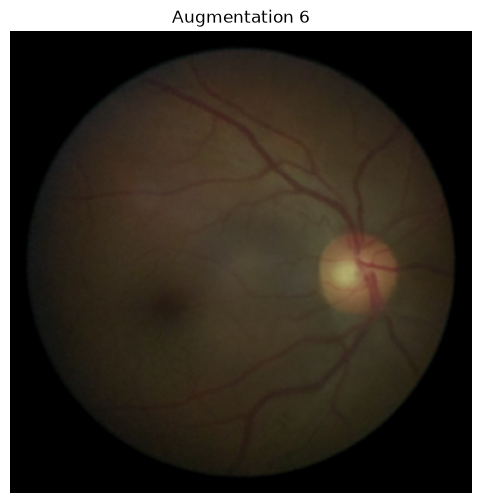

In [12]:
fila_ejemplo = train_df.sample(
    n=1,
    random_state=42
).iloc[0]
ruta = resolver_ruta(
    fila_ejemplo["image_path"]
)
with Image.open(ruta) as img:
    imagen_original = np.array(
        img.convert("RGB")
    )
imagen_base, _ = preprocesar_geometria(
    imagen_original
)
imagen_base = imagen_base.astype(
    np.float32
)

plt.figure(figsize=(6, 6))
plt.imshow(
    imagen_base.astype(np.uint8)
)
plt.title(
    f"Base | {fila_ejemplo['camera']} | "
    f"{fila_ejemplo['original_label']}"
)
plt.axis("off")
plt.show()

for i in range(6):
    aumentada = data_augmentation(
        tf.expand_dims(
            imagen_base,
            axis=0
        ),
        training=True
    )[0]
    aumentada = tf.clip_by_value(
        aumentada,
        0,
        255
    )
    plt.figure(figsize=(6, 6))
    plt.imshow(
        aumentada.numpy().astype(
            np.uint8
        )
    )
    plt.title(
        f"Augmentation {i + 1}"
    )
    plt.axis("off")
    plt.show()


## 13. Tratamiento del desbalance de clases exclusivamente desde Train

Cálculo de las ponderaciones de clase equilibradas (*class weights*) mediante Scikit-learn sobre las 807 imágenes de Train (697 NORMAL vs. 110 GLAUCOMA SUSPECT), sin modificar Validation ni Test.

In [13]:
clases = np.array(
    sorted(
        train_df["label"]
        .unique()
    )
)
pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=train_df["label"].values
)
class_weights = {
    int(clase): float(peso)
    for clase, peso
    in zip(
        clases,
        pesos
    )
}
print(
    class_weights
)


{0: 0.578909612625538, 1: 3.668181818181818}


## 14. Guardar evidencia de los pesos

Estructuración de las ponderaciones calculadas en un DataFrame para su incorporación formal en el argumento `class_weight` durante el entrenamiento de ResNet50V2 y EfficientNetV2-M.

In [14]:
class_weights_df = pd.DataFrame(
    [
        {
            "label": clase,
            "original_label":
                "NORMAL"
                if clase == 0
                else "GLAUCOMA SUSPECT",
            "weight": peso
        }
        for clase, peso
        in class_weights.items()
    ]
)
display(
    class_weights_df
)


,label,original_label,weight
0,0,NORMAL,0.578910
1,1,GLAUCOMA SUSPECT,3.668182


# Conclusiones del pipeline de entrenamiento

Se construyó el pipeline común de entrada que será utilizado posteriormente para los experimentos con ResNet50V2 y EfficientNetV2-M.

Se comprobó que:

- Se utilizan las particiones experimentales previamente congeladas: 807 imágenes de Train, 202 de Validation y 336 de Test.
- El preprocesamiento geométrico previamente validado se reutiliza sin modificaciones.
- Las imágenes son transformadas a tensores de 384 × 384 × 3.
- El Data Augmentation se aplica exclusivamente al subconjunto Train.
- La política de aumentación utiliza flip horizontal, rotaciones pequeñas, zoom isotrópico leve y variaciones moderadas de contraste.
- Validation y Test permanecen sin Data Augmentation.
- Se utiliza un tamaño de lote inicial de 8 imágenes.
- El desbalance de clases se aborda mediante class weights calculados exclusivamente a partir del subconjunto Train.
- Los pesos calculados son aproximadamente 0.579 para NORMAL y 3.668 para GLAUCOMA SUSPECT.
- No se realiza oversampling adicional para evitar aplicar simultáneamente múltiples mecanismos de compensación del desbalance.
- El subconjunto Test queda reservado para la evaluación final y no será utilizado para ajuste de hiperparámetros, selección de épocas o selección de arquitectura.

Este pipeline común permitirá que ResNet50V2 y EfficientNetV2-M sean entrenados bajo las mismas condiciones experimentales, manteniendo los mismos datos, particiones, resolución, política de Data Augmentation y estrategia de manejo del desbalance.